In [ ]:
#Import Libries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [ ]:
#Load The files
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Updated Quality of Life Data.csv')
df.head()

Saving Updated Quality of Life Data.csv to Updated Quality of Life Data (1).csv


,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


In [ ]:
# Get unique values from the occupation_type column
unique_occupations = df['occupation_type'].unique()

print(unique_occupations)

['Teacher' 'Office Worker' 'Manager' 'Freelancer' 'Engineer'
 'Manual Laborer' 'Driver' 'Technician' 'Entrepreneur' 'Retail Worker'
 'Scientist' 'Artist' 'Healthcare Worker' 'Consultant']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


In [ ]:
#Cheaking Missing Value
df.isnull().sum()

,0
id,0
gender,0
occupation_type,0
avg_work_hours_per_day,0
avg_rest_hours_per_day,0
avg_sleep_hours_per_day,0
avg_exercise_hours_per_day,0
age_at_death,0


In [ ]:
# Initialize the LabelEncoder
le = LabelEncoder()

# Convert 'gender' categorical values into numerical format (e.g., 0, 1)
df['gender'] = le.fit_transform(df['gender'])

# Convert 'occupation_type' categorical values into numerical format (e.g., 0, 1, 2, etc.)
df['occupation_type'] = le.fit_transform(df['occupation_type'])

# Display the first few rows of the updated DataFrame
df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,0,12,6.60,10.92,5.38,1.10,88
1,10002,1,9,9.65,7.65,6.31,0.39,76
2,10003,0,7,13.77,1.00,8.02,1.21,78
3,10004,0,5,10.94,5.18,7.59,0.29,74
4,10005,1,3,9.81,5.11,7.38,1.70,78


In [ ]:
# Get unique values from the occupation_type column
unique_occupations = df['occupation_type'].unique()

print(unique_occupations)

[12  9  7  5  3  8  2 13  4 10 11  0  6  1]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  int64  
 2   occupation_type             10000 non-null  int64  
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 625.1 KB


In [ ]:
#Describe the Some Information
df.describe()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,15000.50000,0.489800,6.574000,9.211857,5.964582,7.364192,1.459726,79.85060
std,2886.89568,0.499921,4.041925,2.903739,3.152097,2.214386,0.954428,12.02562
min,10001.00000,0.000000,0.000000,0.010000,0.000000,0.000000,0.000000,25.00000
25%,12500.75000,0.000000,3.000000,7.740000,3.890000,6.310000,0.650000,74.00000
50%,15000.50000,0.000000,7.000000,8.960000,5.830000,7.390000,1.440000,81.00000
75%,17500.25000,1.000000,10.000000,10.440000,7.670000,8.470000,2.250000,88.00000
max,20000.00000,1.000000,13.000000,23.970000,23.930000,19.980000,5.930000,100.00000


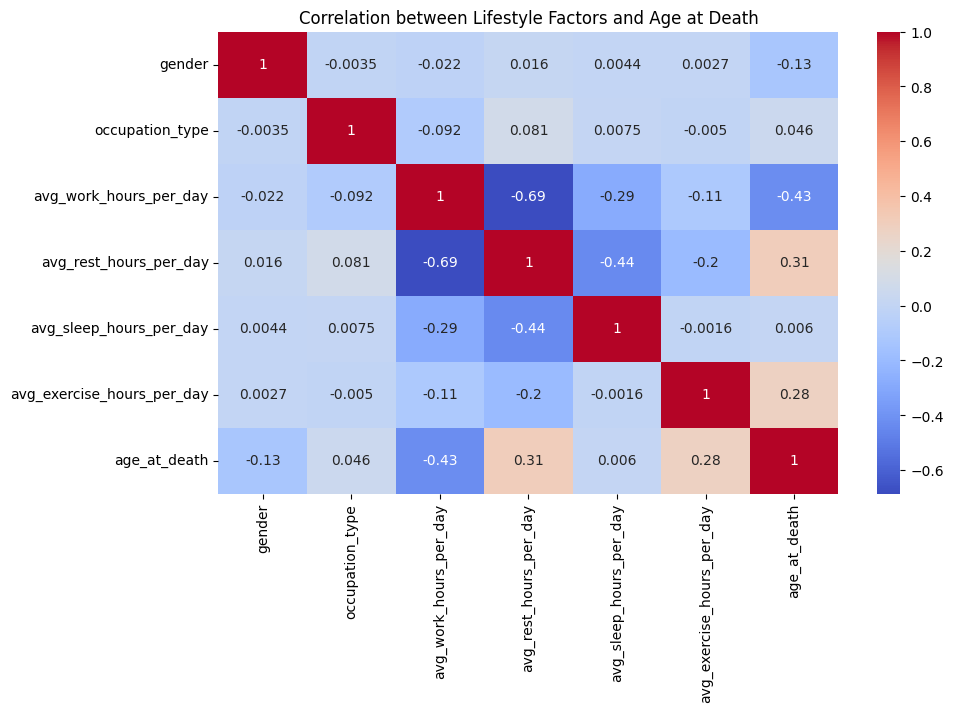

In [ ]:
plt.figure(figsize=(10, 6))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Lifestyle Factors and Age at Death')
plt.show()

In [ ]:
#Data Split the Train Data and Test Data

# Define Features (X) and Target Variable (y)
# We drop 'id' as it is not needed for training, and 'age_at_death' as it is our target
X = df.drop(columns=['id', 'age_at_death'])
y = df['age_at_death']

# Split the dataset into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the Random Forest model
# n_estimators=100 means we are using 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
print("--- Random Forest Evaluation ---")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, rf_predictions):.2f}")
print(f"R2 Score: {r2_score(y_test, rf_predictions):.4f}")

--- Random Forest Evaluation ---
Mean Absolute Error: 6.70
R2 Score: 0.5285


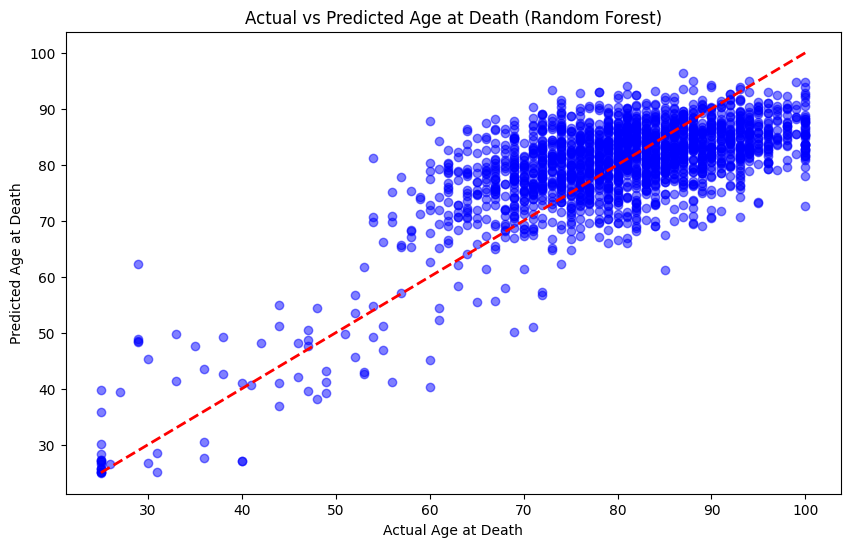

In [ ]:
# 1. Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 45-degree line
plt.xlabel('Actual Age at Death')
plt.ylabel('Predicted Age at Death')
plt.title('Actual vs Predicted Age at Death (Random Forest)')
plt.show()

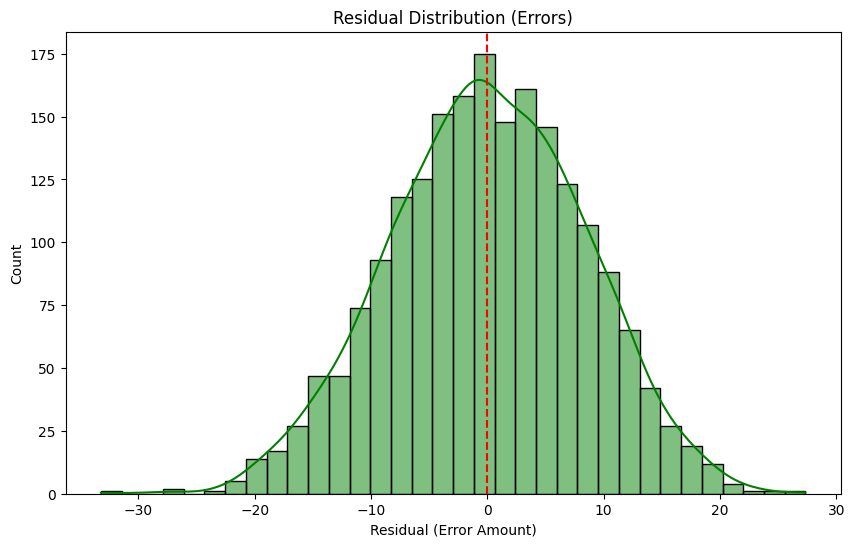

In [ ]:
# 2. Residual Plot
residuals = y_test - rf_predictions
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='green')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residual (Error Amount)')
plt.title('Residual Distribution (Errors)')
plt.show()

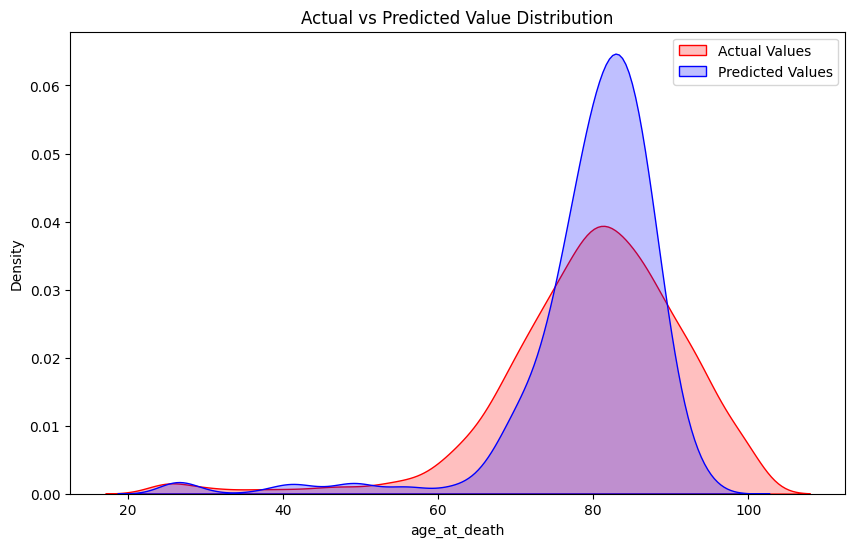

In [ ]:
# 3. Distribution Plot (Actual vs Predicted)
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test, label='Actual Values', color='red', fill=True)
sns.kdeplot(rf_predictions, label='Predicted Values', color='blue', fill=True)
plt.title('Actual vs Predicted Value Distribution')
plt.legend()
plt.show()

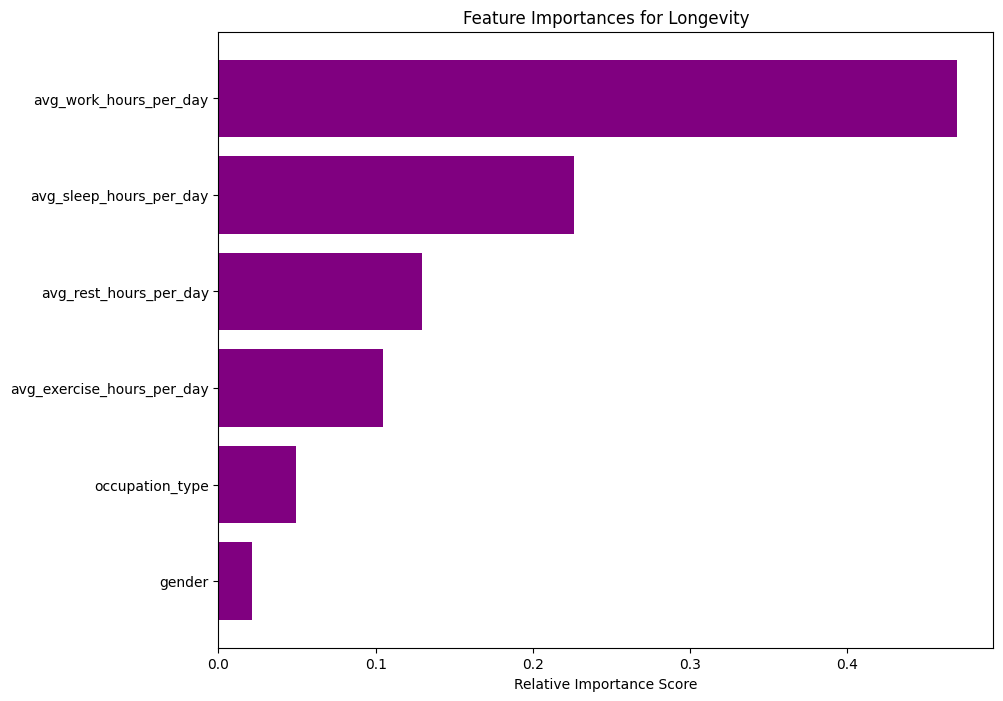

In [ ]:
# Get feature importance from the random forest model
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

# Plotting Feature Importances
plt.figure(figsize=(10, 8))
plt.title('Feature Importances for Longevity')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.show()

In [ ]:
import pickle

# Save the model to a file
with open('growth_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)



print("Model and Encoders saved successfully!")

Model and Encoders saved successfully!
